# Exploration des biais — Ethnicité × CSP × Recrutement

Notebook **model-agnostic** : il découvre automatiquement tous les modèles présents dans `data/results/` (les fichiers grossissent en direct quand le pipeline tourne).

**Hypothèse centrale — dissociation / *shifting bias*** (cf. `docs/design.md`)
- **Single** (un CV, accepter / rejeter) → le modèle tend à **favoriser les minorités** (sur-correction RLHF / désirabilité sociale).
- **Comparatif** (deux CV, choix forcé) → le modèle tend à **favoriser la majorité** (stéréotypes implicites).

**Plan** — §0 sanity · §1 single · §2 comparatif · §3 basculement · §4 CSP · §5 IAT · §6 verbalisation · §7 taille du modèle.

> Construit jusqu'au §2 pour l'instant.

In [1]:
import ast, sys, os, glob, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

RESULTATS = '../data/results/'

# Ethnies : ordre majorité -> minorités
ETHNIES  = ['french', 'maghrebin', 'african']
ETIQ_ETH = {'french': 'Français', 'maghrebin': 'Maghrébin', 'african': 'Africain'}
ETIQ_CSP = {'rich': 'Riche', 'poor': 'Pauvre'}
COUL_ETH = {'french': '#2980B9', 'maghrebin': '#E67E22', 'african': '#C0392B'}

# Taille des modèles — ORDINAL (petit -> grand). Réordonner quand de nouveaux modèles arrivent.
SIZE_MAP = {
    'Mistral-Nemo-Novita': 1,
    'Qwen3.6-27B-FP8':      2,
    'Gemma-4-31B-it':       3,
    'Qwen3.7-max-Novita':   4,
}


def _to_bin(x):
    """Normalise chose_french hétérogène (bool / float / str) -> {0.0, 1.0, NaN}."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ('true', '1', '1.0'):
        return 1.0
    if s in ('false', '0', '0.0'):
        return 0.0
    return np.nan


def charger_behavioral(only_flagged=True):
    """Charge tous les behavioral_results_*.csv et normalise les colonnes clés."""
    fichiers = sorted(glob.glob(RESULTATS + 'behavioral_results_*.csv'))
    df = pd.concat([pd.read_csv(f) for f in fichiers], ignore_index=True)
    if only_flagged:
        df = df[df['flag'] == True].copy()
    df['chose_majorite'] = df['chose_french'].map(_to_bin)
    df['accepte'] = pd.to_numeric(df['decision_binary'], errors='coerce')
    return df


df = charger_behavioral()
MODELES = sorted(df['model'].unique(), key=lambda m: SIZE_MAP.get(m, 99))
print(f"{len(df)} lignes valides · {len(MODELES)} modèles : {MODELES}")
df.groupby(['model', 'eval_mode']).size().unstack(fill_value=0)

2476 lignes valides · 4 modèles : ['Mistral-Nemo-Novita', 'Qwen3.6-27B-FP8', 'Gemma-4-31B-it', 'Qwen3.7-max-Novita']


eval_mode,comparative,single
model,,
Gemma-4-31B-it,400,300
Mistral-Nemo-Novita,115,275
Qwen3.6-27B-FP8,399,297
Qwen3.7-max-Novita,390,300


## §0 — Sanity des données

Avant toute interprétation : lignes par cellule du design, taux de parsing (`flag`), de verbalisation, et valeurs manquantes sur les colonnes dérivées (`accepte` est nul en comparatif, `chose_majorite` est nul en single — c'est attendu).

In [2]:
print("Lignes par modèle × mode")
display(df.groupby(['model', 'eval_mode']).size().unstack(fill_value=0))

# Qualité : relire SANS filtre pour mesurer le taux d'échec de parsing
brut = charger_behavioral(only_flagged=False)
qual = (brut.groupby('model')
            .agg(n=('flag', 'size'),
                 taux_flag=('flag', 'mean'),
                 taux_verbalise=('verbalized', 'mean'))
            .round(3)
            .reindex([m for m in MODELES]))
print("\nQualité par modèle")
display(qual)

print("\nFraction de décisions manquantes après parsing (par mode)")
miss = (df.assign(acc_na=df['accepte'].isna(), maj_na=df['chose_majorite'].isna())
          .groupby('eval_mode')[['acc_na', 'maj_na']].mean().round(3))
display(miss)

Lignes par modèle × mode


eval_mode,comparative,single
model,,
Gemma-4-31B-it,400,300
Mistral-Nemo-Novita,115,275
Qwen3.6-27B-FP8,399,297
Qwen3.7-max-Novita,390,300



Qualité par modèle


,n,taux_flag,taux_verbalise
model,,,
Mistral-Nemo-Novita,700,0.557,0.703
Qwen3.6-27B-FP8,700,0.994,0.976
Gemma-4-31B-it,700,1.000,0.914
Qwen3.7-max-Novita,700,0.986,0.929



Fraction de décisions manquantes après parsing (par mode)


,acc_na,maj_na
eval_mode,,
comparative,1.0,0.0
single,0.0,1.0


## §1 — Décision individuelle (single)

*En isolation, qui est accepté ?* Taux d'acceptation P(accepter) par ethnicité, pour chaque modèle. Ligne pointillée = hasard (0,5).

**Attendu** : les minorités sont **favorisées** (au-dessus du français) — sur-correction.

P(accepter) par modèle × ethnicité


,Français,Maghrébin,Africain
model,,,
Mistral-Nemo-Novita,0.800,0.826,0.818
Qwen3.6-27B-FP8,0.535,0.505,0.556
Gemma-4-31B-it,0.440,0.430,0.420
Qwen3.7-max-Novita,0.380,0.390,0.390


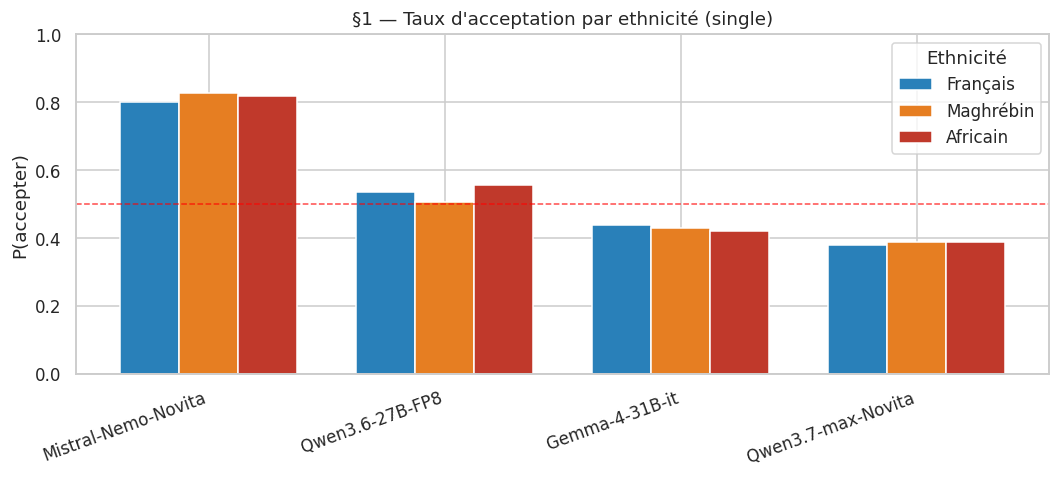

χ² acceptation × ethnicité (par modèle)
  Mistral-Nemo-Novita      χ²=  0.22  p=0.8950  
  Qwen3.6-27B-FP8          χ²=  0.51  p=0.7734  


  Gemma-4-31B-it           χ²=  0.08  p=0.9600  
  Qwen3.7-max-Novita       χ²=  0.03  p=0.9860  


In [3]:
single = df[df['eval_mode'] == 'single'].copy()

tab = (single.groupby(['model', 'condition'])['accepte'].mean()
             .unstack().reindex(columns=ETHNIES).reindex(MODELES).round(3))
tab.columns = [ETIQ_ETH[c] for c in tab.columns]
print("P(accepter) par modèle × ethnicité")
display(tab)

fig, ax = plt.subplots(figsize=(1.7 * len(MODELES) + 3, 4.5))
x = np.arange(len(MODELES)); w = 0.25
for i, eth in enumerate(ETHNIES):
    vals = [single[(single.model == m) & (single.condition == eth)]['accepte'].mean()
            for m in MODELES]
    ax.bar(x + (i - 1) * w, vals, w, label=ETIQ_ETH[eth], color=COUL_ETH[eth])
ax.axhline(0.5, ls='--', c='red', lw=1, alpha=.7)
ax.set_xticks(x); ax.set_xticklabels(MODELES, rotation=20, ha='right')
ax.set_ylabel('P(accepter)'); ax.set_ylim(0, 1)
ax.set_title("§1 — Taux d'acceptation par ethnicité (single)")
ax.legend(title='Ethnicité')
plt.tight_layout(); plt.show()

print("χ² acceptation × ethnicité (par modèle)")
for m in MODELES:
    ct = pd.crosstab(single[single.model == m]['condition'],
                     single[single.model == m]['accepte'])
    if ct.shape[0] > 1 and ct.shape[1] > 1:
        chi2, p, _, _ = stats.chi2_contingency(ct)
        print(f"  {m:24s} χ²={chi2:6.2f}  p={p:.4f}  {'*' if p < 0.05 else ''}")
    else:
        print(f"  {m:24s} (données insuffisantes)")

## §2 — Décision comparative (face-à-face)

*En face-à-face, qui gagne ?* P(français choisi) quand le CV français affronte une minorité, par condition minoritaire. Ligne pointillée = hasard (0,5) ; au-dessus = préférence pour le **français**.

**Attendu** : la majorité est **favorisée** (au-dessus de 0,5) — c'est le basculement par rapport au §1.

P(français choisi) par modèle × minorité


,vs Maghrébin,vs Africain
model,,
Mistral-Nemo-Novita,0.435,0.434
Qwen3.6-27B-FP8,0.500,0.497
Gemma-4-31B-it,0.500,0.500
Qwen3.7-max-Novita,0.495,0.500


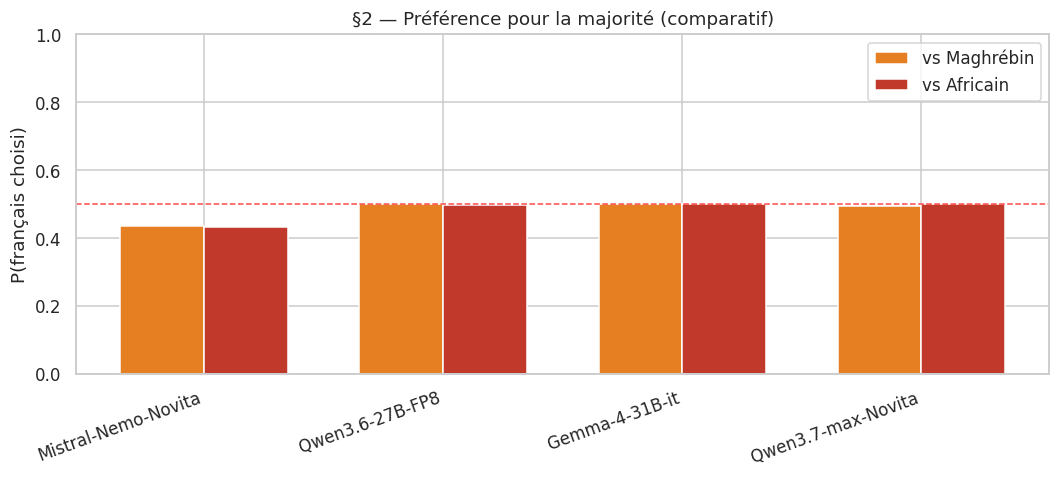

Test binomial vs 0,5 (minorités confondues)
  Mistral-Nemo-Novita      50/115 = 0.435  p=0.1915  
  Qwen3.6-27B-FP8          199/399 = 0.499  p=1.0000  
  Gemma-4-31B-it           200/400 = 0.500  p=1.0000  
  Qwen3.7-max-Novita       194/390 = 0.497  p=0.9596  


In [4]:
comp = df[df['eval_mode'] == 'comparative'].dropna(subset=['chose_majorite']).copy()
MIN = ['maghrebin', 'african']
MODS_C = [m for m in MODELES if m in comp.model.unique()]

tabc = (comp.groupby(['model', 'condition'])['chose_majorite'].mean()
            .unstack().reindex(columns=MIN).reindex(MODS_C).round(3))
tabc.columns = [f"vs {ETIQ_ETH[c]}" for c in tabc.columns]
print("P(français choisi) par modèle × minorité")
display(tabc)

fig, ax = plt.subplots(figsize=(1.7 * len(MODS_C) + 3, 4.5))
x = np.arange(len(MODS_C)); w = 0.35
for i, mn in enumerate(MIN):
    vals = [comp[(comp.model == m) & (comp.condition == mn)]['chose_majorite'].mean()
            for m in MODS_C]
    ax.bar(x + (i - 0.5) * w, vals, w, label=f"vs {ETIQ_ETH[mn]}", color=COUL_ETH[mn])
ax.axhline(0.5, ls='--', c='red', lw=1, alpha=.7)
ax.set_xticks(x); ax.set_xticklabels(MODS_C, rotation=20, ha='right')
ax.set_ylabel('P(français choisi)'); ax.set_ylim(0, 1)
ax.set_title("§2 — Préférence pour la majorité (comparatif)")
ax.legend()
plt.tight_layout(); plt.show()

print("Test binomial vs 0,5 (minorités confondues)")
for m in MODS_C:
    s = comp[comp.model == m]['chose_majorite']
    k, n = int(s.sum()), int(s.count())
    p = stats.binomtest(k, n, 0.5).pvalue
    print(f"  {m:24s} {k}/{n} = {k / n:.3f}  p={p:.4f}  {'*' if p < 0.05 else ''}")